Install Required Libraries


In [1]:
!pip install librosa matplotlib numpy pandas
!pip install kaggle


✅ STEP 1: IMPORT LIBRARIES
These libraries are essential for:

Handling files

Audio processing

Feature extraction

Data manipulation

Model training (later)



In [2]:
# 📚 Core Libraries
import os
import numpy as np
import pandas as pd

# 📈 Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 🎵 Audio Processing
import librosa
import librosa.display
import soundfile as sf

# 🛠 File Handling
from pathlib import Path

# 🧠 Machine Learning (we’ll use later)
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix


✅ STEP 2: MOUNT GOOGLE DRIVE
This gives Colab access to your audio data stored in Google Drive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Step 3: Upload  .wav File

In [ ]:
import glob

# ✅ Set base path to your project folder in Google Drive
base_path = "/content/drive/MyDrive/speech_disorder_project/data"

# ✅ Define paths for normal and disorder audio folders
normal_path = os.path.join(base_path, "normal")
disorder_path = os.path.join(base_path, "disorder")

# ✅ List all .wav files in each folder
normal_files = glob.glob(os.path.join(normal_path, "*.wav"))
disorder_files = glob.glob(os.path.join(disorder_path, "*.wav"))

# ✅ Print the counts
print(f"Number of normal speech files: {len(normal_files)}")
print(f"Number of disordered speech files: {len(disorder_files)}")

# Optional: Preview first few file names
print("\nExample normal files:", normal_files[:3])
print("Example disordered files:", disorder_files[:3])


Number of normal speech files: 9
Number of disordered speech files: 11

Example normal files: ['/content/drive/MyDrive/speech_disorder_project/data/normal/n9.wav', '/content/drive/MyDrive/speech_disorder_project/data/normal/n2.wav', '/content/drive/MyDrive/speech_disorder_project/data/normal/n8.wav']
Example disordered files: ['/content/drive/MyDrive/speech_disorder_project/data/disorder/F_0818_12y4m_1.wav', '/content/drive/MyDrive/speech_disorder_project/data/disorder/F_0811_10y6m_1.wav', '/content/drive/MyDrive/speech_disorder_project/data/disorder/F_0050_10y9m_1.wav']


✅ STEP 4: Extract MFCC Features from All Files
We’ll extract:

MFCCs (Mel-Frequency Cepstral Coefficients) → main speech features

Save them along with their labels (normal or disorder) into a CSV file.

In [ ]:
import librosa
import numpy as np
import pandas as pd
import os
import glob
from tqdm import tqdm  # progress bar

# Paths
base_path = "/content/drive/MyDrive/speech_disorder_project/data"
categories = ["normal", "disorder"]

# Storage for features and labels
features = []
labels = []

# Feature extraction function
def extract_mfcc(file_path):
    try:
        y, sr = librosa.load(file_path, sr=16000)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc.T, axis=0)
        return mfcc_mean
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Process all files
for label in categories:
    path = os.path.join(base_path, label)
    wav_files = glob.glob(os.path.join(path, "*.wav"))

    print(f"Extracting from {label} folder: {len(wav_files)} files")

    for file in tqdm(wav_files):
        mfcc_features = extract_mfcc(file)
        if mfcc_features is not None:
            features.append(mfcc_features)
            labels.append(label)

# Convert to DataFrame
df = pd.DataFrame(features)
df['label'] = labels

# Save to CSV
output_path = "/content/drive/MyDrive/speech_disorder_project/features.csv"
df.to_csv(output_path, index=False)
print(f"\n✅ Feature extraction complete. Saved to {output_path}")


Extracting from normal folder: 9 files


100%|██████████| 9/9 [00:28<00:00,  3.19s/it]


Extracting from disorder folder: 11 files


100%|██████████| 11/11 [00:11<00:00,  1.05s/it]



✅ Feature extraction complete. Saved to /content/drive/MyDrive/speech_disorder_project/features.csv


✅ STEP 5: Train an SVM Model to Classify Speech
We’ll now:

Load features.csv

Encode labels (normal = 0, disorder = 1)

Split into training/testing sets

Train a Support Vector Machine (SVM)

Evaluate performance



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/speech_disorder_project/features.csv")

# Check data shape and class balance
print("✅ Dataset loaded. Shape:", df.shape)
print("🔍 Label counts:\n", df['label'].value_counts())

# Encode labels
df['label'] = df['label'].map({'normal': 0, 'disorder': 1})

# Split features and labels
X = df.drop('label', axis=1)
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train an SVM classifier
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)

# Predict
y_pred = svm_model.predict(X_test)

# Evaluate
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("\n🧾 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


✅ Dataset loaded. Shape: (20, 14)
🔍 Label counts:
 label
disorder    11
normal       9
Name: count, dtype: int64

📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


🧾 Confusion Matrix:
 [[2 0]
 [0 2]]


Step 4: Load and Visualize the Audio
Professional Audio Preprocessing Pipeline
We'll create a clean system to:

✅ Load .wav file properly

✅ Trim leading/trailing silence

✅ Apply optional noise reduction

✅ Visualize:

Waveform

Mel Spectrogram

MFCC heatmap

✅ Extract clean MFCC features (for training)



In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

def preprocess_and_visualize(file_path, sr=16000, n_mfcc=13):
    # Load the audio file
    y, sr = librosa.load(file_path, sr=sr)
    print(f"📄 Loaded '{file_path}' | Duration: {round(len(y)/sr, 2)} sec")

    # Trim silence
    yt, _ = librosa.effects.trim(y)
    print(f"✂️ Trimmed silence | New duration: {round(len(yt)/sr, 2)} sec")

    # Visualize waveform
    plt.figure(figsize=(14, 3))
    librosa.display.waveshow(yt, sr=sr)
    plt.title("Trimmed Audio Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(yt, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
    plt.title("Mel Spectrogram (dB)")
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()

    # MFCC Extraction
    mfcc = librosa.feature.mfcc(y=yt, sr=sr, n_mfcc=n_mfcc)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc, x_axis='time', sr=sr)
    plt.title("MFCC")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    # Return trimmed waveform and MFCC mean
    mfcc_mean = np.mean(mfcc.T, axis=0)
    return yt, mfcc_mean


In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

def preprocess_and_visualize(file_path, sr=16000, n_mfcc=13):
    # Load the audio file
    y, sr = librosa.load(file_path, sr=sr)
    print(f"📄 Loaded '{file_path}' | Duration: {round(len(y)/sr, 2)} sec")

    # Trim silence
    yt, _ = librosa.effects.trim(y)
    print(f"✂️ Trimmed silence | New duration: {round(len(yt)/sr, 2)} sec")

    # Visualize waveform
    plt.figure(figsize=(14, 3))
    librosa.display.waveshow(yt, sr=sr)
    plt.title("Trimmed Audio Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=yt, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
    plt.title("Mel Spectrogram (dB)")
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()

    # MFCC Extraction
    mfcc = librosa.feature.mfcc(y=yt, sr=sr, n_mfcc=n_mfcc)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc, x_axis='time', sr=sr)
    plt.title("MFCC")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    # Return trimmed waveform and MFCC mean
    mfcc_mean = np.mean(mfcc.T, axis=0)
    return yt, mfcc_mean


📄 Loaded '/content/drive/MyDrive/speech_disorder_project/data/normal/n3.wav' | Duration: 43.58 sec
✂️ Trimmed silence | New duration: 43.58 sec


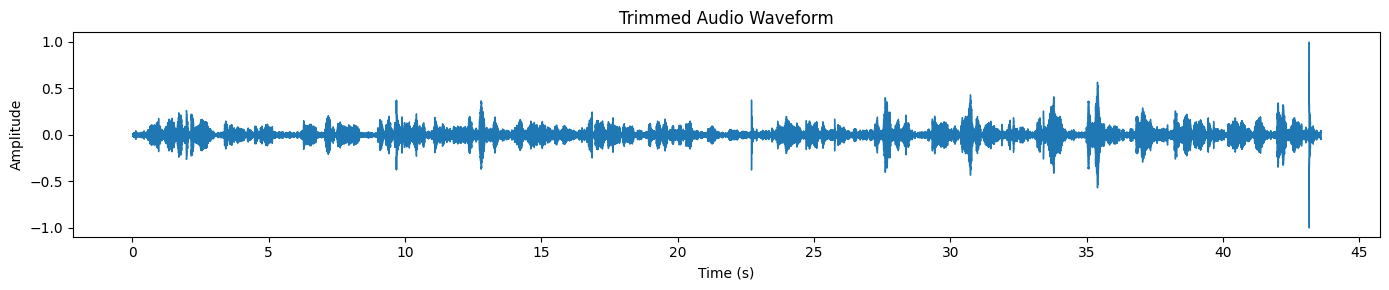

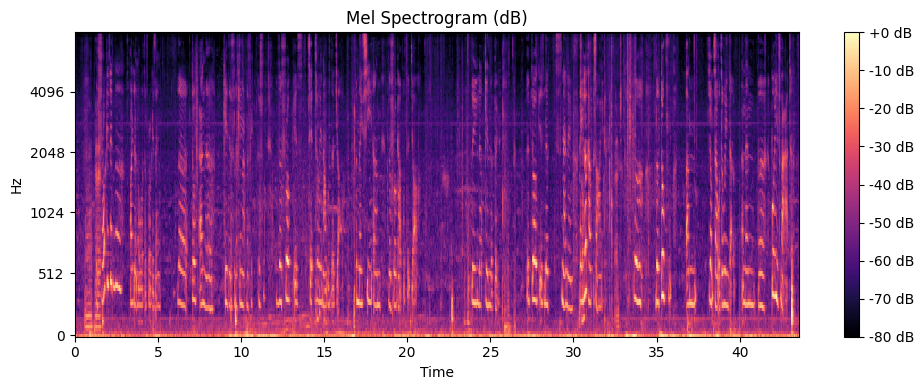

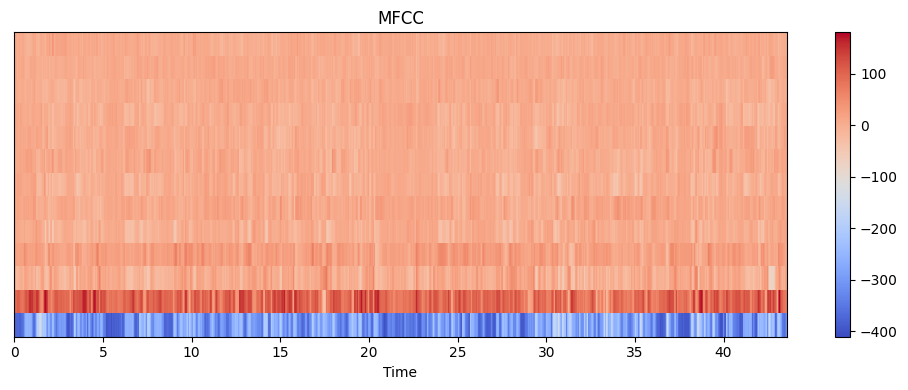

In [ ]:
file_path = "/content/drive/MyDrive/speech_disorder_project/data/normal/n3.wav"
yt, mfcc_features = preprocess_and_visualize(file_path)


Batch Preprocessing and Feature Extraction
We’ll reuse your preprocess_and_visualize() logic — but strip the visualization part (for speed), and apply it in a loop for both categories.

In [ ]:
import os
import glob
from tqdm import tqdm
import librosa
import numpy as np
import pandas as pd

def extract_mfcc_clean(file_path, sr=16000, n_mfcc=13):
    try:
        y, sr = librosa.load(file_path, sr=sr)
        y_trimmed, _ = librosa.effects.trim(y)
        mfcc = librosa.feature.mfcc(y=y_trimmed, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfcc.T, axis=0)
        return mfcc_mean
    except Exception as e:
        print(f"⚠️ Error processing {file_path}: {e}")
        return None

# Set paths
base_path = "/content/drive/MyDrive/speech_disorder_project/data"
categories = ["normal", "disorder"]

features = []
labels = []

for label in categories:
    folder = os.path.join(base_path, label)
    wav_files = glob.glob(os.path.join(folder, "*.wav"))
    print(f"\n🔍 Processing '{label}' ({len(wav_files)} files)")

    for file in tqdm(wav_files):
        mfcc = extract_mfcc_clean(file)
        if mfcc is not None:
            features.append(mfcc)
            labels.append(label)

# Convert to DataFrame
df = pd.DataFrame(features)
df["label"] = labels

# Save cleaned features
output_csv = "/content/drive/MyDrive/speech_disorder_project/cleaned_features.csv"
df.to_csv(output_csv, index=False)
print(f"\n✅ Done! Cleaned features saved to: {output_csv}")



🔍 Processing 'normal' (9 files)


100%|██████████| 9/9 [00:02<00:00,  4.24it/s]



🔍 Processing 'disorder' (11 files)


100%|██████████| 11/11 [00:03<00:00,  3.26it/s]



✅ Done! Cleaned features saved to: /content/drive/MyDrive/speech_disorder_project/cleaned_features.csv


🎯 What This Does:
Iterates through both normal/ and disorder/ folders

Loads each file, trims silence, extracts MFCCs

Saves the cleaned result to cleaned_features.csv

✅ STEP 8: Train Model with Cleaned Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Load the cleaned dataset
df = pd.read_csv("/content/drive/MyDrive/speech_disorder_project/cleaned_features.csv")

# Encode labels
df['label'] = df['label'].map({'normal': 0, 'disorder': 1})

# Split features and target
X = df.drop("label", axis=1)
y = df["label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM model
model = SVC(kernel='linear', probability=True)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate model
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("\n🧾 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


🧾 Confusion Matrix:
 [[2 0]
 [0 2]]


STEP 9: Save the Trained Model

In [ ]:
import joblib

# Save the SVM model
model_path = "/content/drive/MyDrive/speech_disorder_project/svm_model_cleaned.pkl"
joblib.dump(model, model_path)

print(f"✅ Model saved at: {model_path}")


✅ Model saved at: /content/drive/MyDrive/speech_disorder_project/svm_model_cleaned.pkl


🔁 Let's Continue: Model Comparison Phase
We'll use your cleaned MFCC dataset and compare:

* SVM (your current model)



* Random Forest

* Neural Network (MLP)

Then we’ll pick the best one for deployment.

✅ Step 1: Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
rf_pred = rf_model.predict(X_test)
print("🌲 Random Forest Results:")
print("\nClassification Report:\n", classification_report(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))


🌲 Random Forest Results:

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

Confusion Matrix:
 [[2 0]
 [0 2]]


✅ Step 2: Neural Network (MLPClassifier)

In [ ]:
from sklearn.neural_network import MLPClassifier

# Train a simple neural network
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)

# Predict and evaluate
nn_pred = nn_model.predict(X_test)
print("🧠 Neural Network Results:")
print("\nClassification Report:\n", classification_report(y_test, nn_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, nn_pred))


🧠 Neural Network Results:

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

Confusion Matrix:
 [[2 0]
 [0 2]]


✅ Objective:

Download normal child speech data from Kaggle (CMU Kids Dataset)

In [3]:
from google.colab import files
files.upload()  # Upload the kaggle.json here


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sachinmoktan","key":"ead6ec693824ee09313a919a13db720f"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


🔹 STEP 3: Install Kaggle and Download Dataset

In [5]:
!pip install kaggle
!kaggle datasets download -d rtatman/children-speech-recognition-dataset
!unzip children-speech-recognition-dataset.zip -d /content/data/normal/

403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/datasets/metadata/rtatman/children-speech-recognition-dataset
unzip:  cannot find or open children-speech-recognition-dataset.zip, children-speech-recognition-dataset.zip.zip or children-speech-recognition-dataset.zip.ZIP.


✅ How to Move Data to Your Google Drive


Run the following code to mount your Google Drive:

In [6]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
!cp -r /content/data/normal /content/drive/MyDrive/speech_disorder_project/data/


cp: cannot stat '/content/data/normal': No such file or directory


In [8]:
!unzip children-speech-recognition-dataset.zip -d /content/data/normal/


unzip:  cannot find or open children-speech-recognition-dataset.zip, children-speech-recognition-dataset.zip.zip or children-speech-recognition-dataset.zip.ZIP.


In [9]:
!ls -lh


total 12K
drwx------ 6 root root 4.0K May 31 07:49 drive
-rw-r--r-- 1 root root   68 May 31 07:42 kaggle.json
drwxr-xr-x 1 root root 4.0K May 29 14:01 sample_data


In [10]:
!mkdir -p /content/data/normal
!unzip -q children-speech-recognition-dataset.zip -d /content/data/normal


unzip:  cannot find or open children-speech-recognition-dataset.zip, children-speech-recognition-dataset.zip.zip or children-speech-recognition-dataset.zip.ZIP.


In [11]:
!pip install -q kaggle


In [12]:
from google.colab import files
files.upload()  # Upload kaggle.json here


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"sachinmoktan","key":"ead6ec693824ee09313a919a13db720f"}'}

In [14]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [15]:
!kaggle datasets download -d rtatman/children-speech-recognition-dataset


403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/datasets/metadata/rtatman/children-speech-recognition-dataset


🚀 So Here’s What We’ll Do Next:


✅ Step 1: Apply Voice Activity Detection (VAD)
Split your long .wav files into clean, short speech segments

Remove silent or irrelevant parts

Once VAD is done, we'll proceed with:


✅ Step 2: Preprocessing (resample, normalize)

✅ Step 3: Feature Extraction (MFCC, etc.)

✅ Step 4: Model Training

⚡ Let’s Start with VAD
Just confirm:

✅ What is the folder path inside your Drive where the raw .wav files are stored?
Example:

In [20]:


path = "/content/drive/MyDrive/speech_disorder_project/data/normal"


In [21]:
import os

path = "/content/drive/MyDrive/speech_disorder_project/data/normal"
files = os.listdir(path)

print("Number of files:", len(files))
print("Example files:", files[:5])


Number of files: 48
Example files: ['5047.wav', 'n9.wav', 'n2.wav', 'n8.wav', 'n3.wav']


🔧 What We'll Do Now:
Use webrtcvad + pydub to:

*  Detect where speech occurs

* Split long files into smaller speech-only .wav clips (~3–5 seconds)

* Save those clips to a new folder



In [22]:
!pip install webrtcvad pydub
!apt-get install -y ffmpeg


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for webrtcvad: filename=webrtcvad-2.0.10-cp311-cp311-linux_x86_64.whl size=73498 sha256=2c0f33836bd560411bf6629fb10d0929e3f1e2c8193db6ff7b9a77aa9f05d665
  Stored in directory: /root/.cache/pip/wheels/94/65/3f/292d0b656be33d1c801831201c74b5f68f41a2ae465ff2ee2f
Successfully built webrtcvad
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import os

input_path = "/content/drive/MyDrive/speech_disorder_project/data/normal"  # Folder with long .wav files
output_path = "/content/drive/MyDrive/speech_disorder_project/processed/normal"  # Folder to store VAD clips

os.makedirs(output_path, exist_ok=True)


🎙️ Step 4: VAD-Based Audio Split Function

In [27]:
def vad_split(file_path, out_dir, aggressiveness=2):
    from pydub import AudioSegment
    import webrtcvad

    # Load and convert to 16kHz mono 16-bit PCM
    audio = AudioSegment.from_file(file_path)
    audio = audio.set_channels(1).set_frame_rate(16000).set_sample_width(2)

    vad = webrtcvad.Vad(aggressiveness)
    frame_duration = 30  # must be 10, 20, or 30 ms
    frame_size = int(16000 * frame_duration / 1000) * 2  # 2 bytes per sample

    raw_audio = audio.raw_data
    segments = []
    start = 0
    triggered = False
    temp_chunk = b''

    for i in range(0, len(raw_audio), frame_size):
        frame = raw_audio[i:i + frame_size]
        if len(frame) < frame_size:
            break
        is_speech = vad.is_speech(frame, 16000)

        if is_speech:
            triggered = True
            temp_chunk += frame
        elif triggered:
            if len(temp_chunk) > 16000 * 2 * 1:  # at least 1 second
                segment_audio = AudioSegment(
                    data=temp_chunk, sample_width=2, frame_rate=16000, channels=1
                )
                segments.append(segment_audio)
            temp_chunk = b''
            triggered = False

    # Save segments
    basename = os.path.splitext(os.path.basename(file_path))[0]
    for i, segment in enumerate(segments):
        out_path = os.path.join(out_dir, f"{basename}_{i:03d}.wav")
        segment.export(out_path, format='wav')


🚀 Step 5: Apply VAD to All Normal Files

In [28]:
for file in os.listdir(input_path):
    if file.endswith(".wav"):
        print(f"Processing {file}...")
        full_path = os.path.join(input_path, file)
        vad_split(full_path, output_path)


Processing 5047.wav...
Processing n9.wav...
Processing n2.wav...
Processing n8.wav...
Processing n3.wav...
Processing n1.wav...
Processing n5.wav...
Processing n6.wav...
Processing n7.wav...
Processing n4.wav...
Processing 5048.wav...
Processing 4009.wav...
Processing 4024.wav...
Processing 4028.wav...
Processing 4026.wav...
Processing 5427.wav...
Processing 5011.wav...
Processing 5007.wav...
Processing 4016.wav...
Processing 5010.wav...
Processing 5008.wav...
Processing 5009.wav...
Processing 4013.wav...
Processing 4002.wav...
Processing 9036.wav...
Processing 4001.wav...
Processing 9042.wav...
Processing 9001.wav...
Processing 9043.wav...
Processing 8042.wav...
Processing 7022.wav...
Processing 9011.wav...
Processing 9033.wav...
Processing 8017.wav...
Processing 8053.wav...
Processing 7064.wav...
Processing 7003.wav...
Processing 8039.wav...
Processing 8050.wav...
Processing 6060.wav...
Processing 6002.wav...
Processing 6052.wav...
Processing 7037.wav...
Processing 6050.wav...
Proces

✅ Step 3: Verify Output

In [29]:
!ls /content/drive/MyDrive/speech_disorder_project/processed/normal | head


4001_000.wav
4001_001.wav
4001_002.wav
4001_003.wav
4001_004.wav
4001_005.wav
4001_006.wav
4001_007.wav
4001_008.wav
4001_009.wav


✅ Why Trimming, Visualizing, and Normalizing Are Important

1. Trimming (Silence removal)
*  Cuts off long silent segments

*  Keeps audio focused on meaningful speech

* Speeds up training, reduces noise

2. Loading and Visualizing
* Helps confirm that the audio is:

 * Not corrupted

 * Has expected length

 * Contains speech and not just noise or silence

* Visualization (waveforms, spectrograms) makes your project look more professional and explainable in your report

3. Normalization
* Brings all audio to a consistent volume level

* Ensures features aren’t biased due to loudness

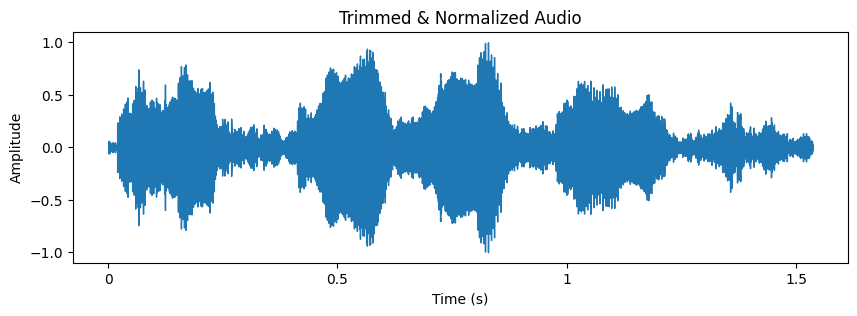

In [30]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

file_path = "/content/drive/MyDrive/speech_disorder_project/processed/normal/n1_000.wav"

# Load audio
y, sr = librosa.load(file_path, sr=16000)

# Trim silence
yt, _ = librosa.effects.trim(y, top_db=20)

# Normalize
yt = yt / np.max(np.abs(yt))

# Plot waveform
plt.figure(figsize=(10, 3))
librosa.display.waveshow(yt, sr=sr)
plt.title("Trimmed & Normalized Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


🔁 Apply to All Files Before Feature Extraction

You can also apply the trim + normalize step before MFCC extraction in your feature loop:

In [31]:
y, sr = librosa.load(file_path, sr=16000)
yt, _ = librosa.effects.trim(y, top_db=20)
yt = yt / np.max(np.abs(yt))  # Normalize
mfccs = librosa.feature.mfcc(y=yt, sr=sr, n_mfcc=20)


🎯 Goal:
For each .wav file:

✅ Trim leading & trailing silence

✅ Normalize the audio

✅ Overwrite or save cleaned files in a new folder (recommended)

🛠 Step-by-Step: Preprocess All Files (Google Colab)

📁 Step 1: Set Paths

In [32]:
import os
from pydub import AudioSegment
import librosa
import numpy as np

input_path = "/content/drive/MyDrive/speech_disorder_project/processed/normal"
output_path = "/content/drive/MyDrive/speech_disorder_project/preprocessed/normal"
os.makedirs(output_path, exist_ok=True)


✂️ Step 2: Define Trim & Normalize Function

In [33]:
def trim_and_normalize(file_path, output_path):
    y, sr = librosa.load(file_path, sr=16000)

    # Trim silence
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)

    # Normalize audio
    y_norm = y_trimmed / np.max(np.abs(y_trimmed))

    # Save processed file
    filename = os.path.basename(file_path)
    out_file = os.path.join(output_path, filename)
    librosa.output.write_wav(out_file, y_norm, sr)


In [34]:
import soundfile as sf

def trim_and_normalize(file_path, output_path):
    y, sr = librosa.load(file_path, sr=16000)
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)
    y_norm = y_trimmed / np.max(np.abs(y_trimmed))
    out_file = os.path.join(output_path, os.path.basename(file_path))
    sf.write(out_file, y_norm, sr)


🔁 Step 3: Apply to All Files

In [35]:
for file in os.listdir(input_path):
    if file.endswith(".wav"):
        file_path = os.path.join(input_path, file)
        try:
            trim_and_normalize(file_path, output_path)
            print(f"✅ Processed: {file}")
        except Exception as e:
            print(f"❌ Failed: {file} - {e}")


Streaming output truncated to the last 5000 lines.
✅ Processed: n4_002.wav
✅ Processed: n4_003.wav
✅ Processed: n4_004.wav
✅ Processed: n4_005.wav
✅ Processed: n4_006.wav
✅ Processed: n4_007.wav
✅ Processed: n4_008.wav
✅ Processed: n4_009.wav
✅ Processed: n4_010.wav
✅ Processed: n4_011.wav
✅ Processed: n4_012.wav
✅ Processed: n4_013.wav
✅ Processed: n4_014.wav
✅ Processed: n4_015.wav
✅ Processed: n4_016.wav
✅ Processed: 5048_000.wav
✅ Processed: 5048_001.wav
✅ Processed: 5048_002.wav
✅ Processed: 5048_003.wav
✅ Processed: 5048_004.wav
✅ Processed: 5048_005.wav
✅ Processed: 5048_006.wav
✅ Processed: 5048_007.wav
✅ Processed: 5048_008.wav
✅ Processed: 5048_009.wav
✅ Processed: 5048_010.wav
✅ Processed: 5048_011.wav
✅ Processed: 5048_012.wav
✅ Processed: 5048_013.wav
✅ Processed: 5048_014.wav
✅ Processed: 5048_015.wav
✅ Processed: 5048_016.wav
✅ Processed: 5048_017.wav
✅ Processed: 5048_018.wav
✅ Processed: 5048_019.wav
✅ Processed: 5048_020.wav
✅ Processed: 5048_021.wav
✅ Processed: 5048

🔁 Let’s Do VAD for Disordered Files

Here’s a quick reminder of how to apply VAD using our earlier vad_split() function.

📁 Step 1: Set the Input/Output Folders

In [36]:
input_disorder = "/content/drive/MyDrive/speech_disorder_project/data/disorder"
output_disorder_vad = "/content/drive/MyDrive/speech_disorder_project/processed/disorder"
os.makedirs(output_disorder_vad, exist_ok=True)


🎙️ Step 2: Apply vad_split() to All Files

In [43]:
def vad_split(file_path, out_dir, aggressiveness=2):
    from pydub import AudioSegment
    import webrtcvad

    audio = AudioSegment.from_file(file_path)
    audio = audio.set_channels(1).set_frame_rate(16000).set_sample_width(2)

    vad = webrtcvad.Vad(aggressiveness)
    frame_duration = 30
    frame_size = int(16000 * frame_duration / 1000) * 2

    raw_audio = audio.raw_data
    segments = []
    triggered = False
    temp_chunk = b''

    for i in range(0, len(raw_audio), frame_size):
        frame = raw_audio[i:i + frame_size]
        if len(frame) < frame_size:
            break
        is_speech = vad.is_speech(frame, 16000)
        if is_speech:
            triggered = True
            temp_chunk += frame
        elif triggered:
            if len(temp_chunk) > 16000 * 2 * 1:
                segment_audio = AudioSegment(data=temp_chunk, sample_width=2, frame_rate=16000, channels=1)
                segments.append(segment_audio)
            temp_chunk = b''
            triggered = False

    basename = os.path.splitext(os.path.basename(file_path))[0]
    for i, segment in enumerate(segments):
        out_file = os.path.join(out_dir, f"{basename}_{i:03d}.wav")
        segment.export(out_file, format='wav')


In [47]:
for file in os.listdir(input_disorder):
    if file.endswith(".wav"):
        full_path = os.path.join(input_disorder, file)
        print(f"Processing {file}...")
        vad_split(full_path, output_disorder_vad)


Processing F_0818_14y2m_1.wav...
Processing F_0879_12y5m_1.wav...
Processing F_0988_12y8m_1.wav...
Processing F_1039_09y3m_1.wav...
Processing F_1116_09y6m_1.wav...
Processing F_0987_12y8m_1.wav...
Processing F_0988_13y6m_1.wav...
Processing M_0017_09y0m_1.wav...
Processing M_0028_15y11m_1.wav...
Processing M_0030_12y1m_1.wav...
Processing M_0030_12y1m_2.wav...
Processing M_0017_08y9m_1.wav...
Processing M_0017_09y4m_1.wav...
Processing M_0030_16y4m_1.wav...
Processing M_0030_13y1m_1.wav...
Processing M_0030_12y9m_1.wav...
Processing M_0030_12y7m_1.wav...
Processing M_0030_19y5m_1.wav...
Processing M_0052_12y8m_1.wav...
Processing M_0030_17y9m_1.wav...
Processing M_0052_12y10m_1.wav...
Processing M_0052_16y4m_1.wav...
Processing M_0061_14y7m_1.wav...
Processing M_0052_14y4m_1.wav...
Processing M_0061_14y1m_2.wav...
Processing M_0061_14y1m_1.wav...
Processing M_0061_14y3m_1.wav...
Processing M_0052_13y1m_1.wav...
Processing M_0061_14y9m_1.wav...
Processing M_0061_14y8m_1.wav...
Processi

🎯 Now: Trim + Normalize Disordered Speech

In [49]:
!ls /content/drive/MyDrive/speech_disorder_project/processed/disorder | head


F_0050_10y9m_1_000.wav
F_0050_10y9m_1_001.wav
F_0050_10y9m_1_002.wav
F_0050_10y9m_1_003.wav
F_0050_10y9m_1_004.wav
F_0050_10y9m_1_005.wav
F_0050_10y9m_1_006.wav
F_0050_10y9m_1_007.wav
F_0050_10y9m_1_008.wav
F_0050_10y9m_1_009.wav


In [52]:
!ls /content/drive/MyDrive/speech_disorder_project/preprocessed/disorder | head


ls: cannot access '/content/drive/MyDrive/speech_disorder_project/preprocessed/disorder': No such file or directory


In [53]:
import os

input_disorder = "/content/drive/MyDrive/speech_disorder_project/processed/disorder"
output_disorder = "/content/drive/MyDrive/speech_disorder_project/preprocessed/disorder"
os.makedirs(output_disorder, exist_ok=True)


✂️ Step 2: Use the Same Trimming & Normalization Function

In [55]:
import librosa
import numpy as np
import soundfile as sf

def trim_and_normalize(file_path, output_path):
    y, sr = librosa.load(file_path, sr=16000)
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)
    y_norm = y_trimmed / np.max(np.abs(y_trimmed))
    out_file = os.path.join(output_path, os.path.basename(file_path))
    sf.write(out_file, y_norm, sr)


🔁 Step 3: Process All Disordered Clips

In [56]:
for file in os.listdir(input_disorder):
    if file.endswith(".wav"):
        file_path = os.path.join(input_disorder, file)
        try:
            trim_and_normalize(file_path, output_disorder)
            print(f"✅ Processed: {file}")
        except Exception as e:
            print(f"❌ Failed: {file} - {e}")


Streaming output truncated to the last 5000 lines.
✅ Processed: F_0988_13y6m_1_017.wav
✅ Processed: F_0988_13y6m_1_018.wav
✅ Processed: F_0988_13y6m_1_019.wav
✅ Processed: M_0017_09y0m_1_000.wav
✅ Processed: M_0017_09y0m_1_001.wav
✅ Processed: M_0017_09y0m_1_002.wav
✅ Processed: M_0017_09y0m_1_003.wav
✅ Processed: M_0017_09y0m_1_004.wav
✅ Processed: M_0017_09y0m_1_005.wav
✅ Processed: M_0017_09y0m_1_006.wav
✅ Processed: M_0017_09y0m_1_007.wav
✅ Processed: M_0017_09y0m_1_008.wav
✅ Processed: M_0017_09y0m_1_009.wav
✅ Processed: M_0017_09y0m_1_010.wav
✅ Processed: M_0017_09y0m_1_011.wav
✅ Processed: M_0017_09y0m_1_012.wav
✅ Processed: M_0017_09y0m_1_013.wav
✅ Processed: M_0017_09y0m_1_014.wav
✅ Processed: M_0017_09y0m_1_015.wav
✅ Processed: M_0017_09y0m_1_016.wav
✅ Processed: M_0017_09y0m_1_017.wav
✅ Processed: M_0017_09y0m_1_018.wav
✅ Processed: M_0017_09y0m_1_019.wav
✅ Processed: M_0017_09y0m_1_020.wav
✅ Processed: M_0017_09y0m_1_021.wav
✅ Processed: M_0017_09y0m_1_022.wav
✅ Processed: 

🎯 Objective:

Extract 20 MFCCs from each file

Take average across time axis

Save to CSV: features_normal.csv and features_disorder.csv

Merge them into a single features.csv

📦 Step 1: Import Libraries

In [57]:
import os
import librosa
import numpy as np
import pandas as pd


📁 Step 2: Define MFCC Extractor

In [58]:
def extract_features(folder_path, label):
    data = []
    for file in os.listdir(folder_path):
        if file.endswith(".wav"):
            try:
                file_path = os.path.join(folder_path, file)
                y, sr = librosa.load(file_path, sr=16000)
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
                mfcc_mean = np.mean(mfcc.T, axis=0)
                data.append(np.append(mfcc_mean, label))
            except Exception as e:
                print(f"Error processing {file}: {e}")
    return data


🧠 Step 3: Run on Both Normal and Disorder

In [59]:
normal_path = "/content/drive/MyDrive/speech_disorder_project/preprocessed/normal"
disorder_path = "/content/drive/MyDrive/speech_disorder_project/preprocessed/disorder"

features_normal = extract_features(normal_path, label=0)
features_disorder = extract_features(disorder_path, label=1)


📊 Step 4: Combine and Save to CSV

In [60]:
all_features = features_normal + features_disorder

columns = [f"mfcc{i+1}" for i in range(20)] + ["label"]
df = pd.DataFrame(all_features, columns=columns)

output_path = "/content/drive/MyDrive/speech_disorder_project/features/features.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df.to_csv(output_path, index=False)

print(f"✅ Features saved to {output_path}")


✅ Features saved to /content/drive/MyDrive/speech_disorder_project/features/features.csv


🧠 Step-by-Step: Random Forest Model Training

📦 Step 1: Import Required Libraries

In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


📂 Step 2: Load the Dataset

In [62]:
df = pd.read_csv('/content/drive/MyDrive/speech_disorder_project/features/features.csv')
print(df.head())


        mfcc1      mfcc2      mfcc3      mfcc4      mfcc5      mfcc6  \
0  -55.336060  62.685860   8.284142  14.557733  -0.451641  -6.096270   
1  -56.220058  68.958725   3.018561  -4.990329  -5.546426   5.172944   
2  -84.741310  83.112114  -4.387438  14.003525  -5.539241  -5.820259   
3 -100.049034  92.441177   1.329110  32.162498 -13.573905 -19.190535   
4 -121.269348  81.137794 -17.767708   8.114376 -12.348757   3.744908   

      mfcc7     mfcc8      mfcc9     mfcc10  ...    mfcc12    mfcc13  \
0  1.186673  0.223899   9.478741   8.118732  ...  2.225830  0.093420   
1  4.152747 -5.772617   4.940377   8.922370  ...  0.291398 -3.020219   
2 -4.170841 -5.340782   8.291325  -2.901850  ...  2.711611 -0.284456   
3  3.457921 -9.921641   5.474404  15.174060  ...  5.827557  6.247514   
4  6.883042 -3.676867  13.016993   4.045404  ... -1.569206 -5.420131   

     mfcc14     mfcc15    mfcc16     mfcc17     mfcc18     mfcc19     mfcc20  \
0  2.084177   0.201342 -1.141851   2.665609   2.010776

🔀 Step 3: Split Into Train & Test Sets

In [63]:
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


🌳 Step 4: Train the Random Forest Classifier

In [64]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

📊 Step 5: Evaluate the Model

In [65]:
y_pred = model.predict(X_test)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n🔍 Classification Report:\n", classification_report(y_test, y_pred))
print("\n📉 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


✅ Accuracy: 0.9788563190773667

🔍 Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      1053
         1.0       0.98      0.98      0.98      1028

    accuracy                           0.98      2081
   macro avg       0.98      0.98      0.98      2081
weighted avg       0.98      0.98      0.98      2081


📉 Confusion Matrix:
 [[1032   21]
 [  23 1005]]


Saving the model


In [69]:
import os

model_dir = "/content/drive/MyDrive/speech_disorder_project/model"
os.makedirs(model_dir, exist_ok=True)


In [70]:
joblib.dump(model, os.path.join(model_dir, "random_forest_model.pkl"))


['/content/drive/MyDrive/speech_disorder_project/model/random_forest_model.pkl']

In [71]:
import os
import joblib

model_dir = "/content/drive/MyDrive/speech_disorder_project/model"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(model, os.path.join(model_dir, "random_forest_model.pkl"))
print("✅ Model saved successfully!")


✅ Model saved successfully!


🎯 What We’ll Do (Neural Network Training Plan)
* Load your feature dataset again

* Normalize features for NN (important!)

* Build a basic feedforward neural network

* Train it on your data

* Evaluate performance



✅ Step-by-Step: Neural Network for Speech Disorder Classification

📦 Step 1: Import Libraries

In [72]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


📂 Step 2: Load & Prepare Data

In [73]:
df = pd.read_csv('/content/drive/MyDrive/speech_disorder_project/features/features.csv')

X = df.drop('label', axis=1).values
y = df['label'].values


📏 Step 3: Normalize Features & One-Hot Encode Labels

In [74]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_categorical = to_categorical(y, num_classes=2)  # Binary classification (Normal vs Disorder)


🧪 Step 4: Train/Test Split

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_categorical, test_size=0.2, random_state=42)


🧠 Step 5: Build Neural Network Model

In [76]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X.shape[1],)),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')  # 2 classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,490 (13.63 KB)

 Trainable params: 3,490 (13.63 KB)

 Non-trainable params: 0 (0.00 B)

🚀 Step 6: Train the Model

In [77]:
history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_split=0.1)


Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9240 - loss: 0.1965 - val_accuracy: 0.9760 - val_loss: 0.0753
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9777 - loss: 0.0652 - val_accuracy: 0.9808 - val_loss: 0.0567
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9846 - loss: 0.0456 - val_accuracy: 0.9856 - val_loss: 0.0514
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9879 - loss: 0.0331 - val_accuracy: 0.9844 - val_loss: 0.0455
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9873 - loss: 0.0312 - val_accuracy: 0.9880 - val_loss: 0.0406
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9921 - loss: 0.0237 - val_accuracy: 0.9868 - val_loss: 0.0407
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9941 - loss: 0.0193 - val_accuracy: 0.9868 - val_loss: 0.0421
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9939 - loss: 0.0191 - val_accuracy: 0.

🧾 Step 7: Evaluate the Model

In [78]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\n✅ Neural Network Accuracy: {accuracy*100:.2f}%")


66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9844 - loss: 0.1031

✅ Neural Network Accuracy: 98.17%


💾 Save the Neural Network Model

In [79]:
model.save('/content/drive/MyDrive/speech_disorder_project/model/nn_model.h5')
print("✅ NN model saved as nn_model.h5")


✅ NN model saved as nn_model.h5


In [84]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [85]:
import joblib
joblib.dump(scaler, '/content/drive/MyDrive/speech_disorder_project/model/scaler.pkl')


['/content/drive/MyDrive/speech_disorder_project/model/scaler.pkl']

Evaluation for both model


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
project_path = "/content/drive/MyDrive/speech_disorder_project"
model_path = f"{project_path}/model"
data_path = f"{project_path}/data"


Regenerate the train/test split

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
import joblib
from sklearn.preprocessing import StandardScaler

# Load all features
df = pd.read_csv("/content/drive/MyDrive/speech_disorder_project/features/features.csv")

# Split features and labels
X = df.drop("label", axis=1)
y = df["label"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
joblib.dump(scaler, "/content/drive/MyDrive/speech_disorder_project/model/scaler.pkl")

# Save test data for evaluation later
X_test.to_csv("/content/drive/MyDrive/speech_disorder_project/data/X_test.csv", index=False)
y_test.to_csv("/content/drive/MyDrive/speech_disorder_project/data/y_test.csv", index=False)


📦 3. Load test data and scaler

In [6]:
import joblib
import pandas as pd

# Load data
X_test = pd.read_csv(f"{data_path}/X_test.csv")
y_test = pd.read_csv(f"{data_path}/y_test.csv").values.ravel()

# Load model and scaler
rf_model = joblib.load(f"{model_path}/random_forest_model.pkl")
scaler = joblib.load(f"{model_path}/scaler.pkl")

# Scale the test set
X_test_scaled = scaler.transform(X_test)


🧪 Step: Evaluate Random Forest Model

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


📊 Classification Report (Random Forest):
               precision    recall  f1-score   support

         0.0       0.85      0.02      0.04      1039
         1.0       0.51      1.00      0.67      1042

    accuracy                           0.51      2081
   macro avg       0.68      0.51      0.36      2081
weighted avg       0.68      0.51      0.36      2081

✅ Accuracy: 0.5093704949543488
📈 ROC-AUC: 0.6503706686814983


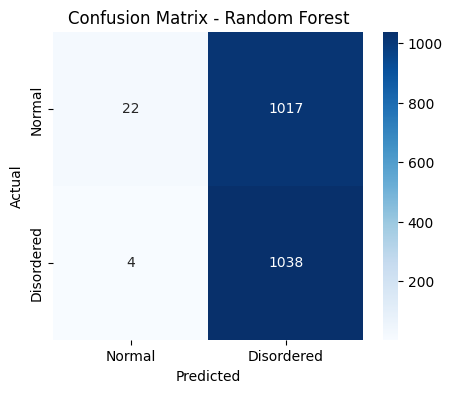

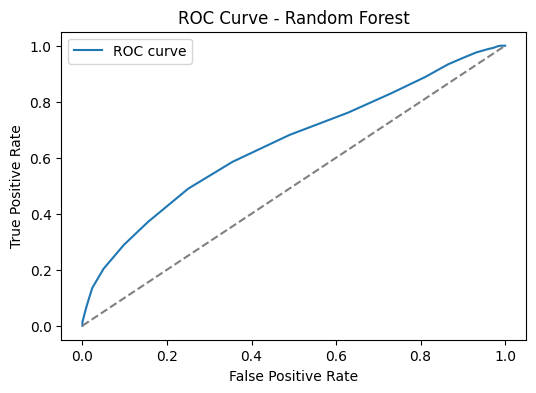

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# 🧪 Random Forest Evaluation
y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# 🔍 Reports
print("📊 Classification Report (Random Forest):\n", classification_report(y_test, y_pred))
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("📈 ROC-AUC:", roc_auc_score(y_test, y_proba))

# 📉 Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues",
            xticklabels=['Normal', 'Disordered'], yticklabels=['Normal', 'Disordered'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 📈 ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()


🧠 Step: Evaluate Neural Network (Keras)

In [15]:
# Predict probability distribution for each sample
nn_pred_probs = nn_model.predict(X_test_scaled)

# Choose class with higher probability (argmax across axis 1)
nn_pred = np.argmax(nn_pred_probs, axis=1)


66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


🧪 Evaluate NN Model

In [16]:
from sklearn.metrics import classification_report, accuracy_score

print("📊 Classification Report (Neural Network):\n")
print(classification_report(y_test, nn_pred))

accuracy = accuracy_score(y_test, nn_pred)
print(f"✅ Accuracy: {accuracy:.4f}")


📊 Classification Report (Neural Network):

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      1039
         1.0       1.00      0.99      1.00      1042

    accuracy                           1.00      2081
   macro avg       1.00      1.00      1.00      2081
weighted avg       1.00      1.00      1.00      2081

✅ Accuracy: 0.9952


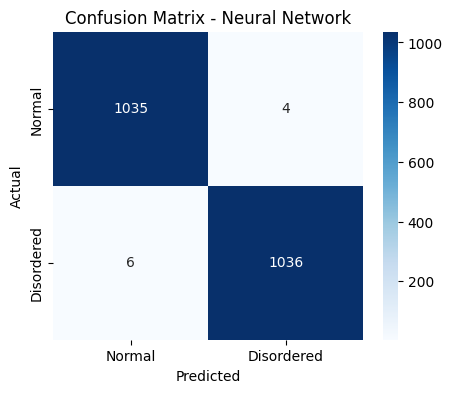

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, nn_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Disordered'],
            yticklabels=['Normal', 'Disordered'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Neural Network')
plt.show()


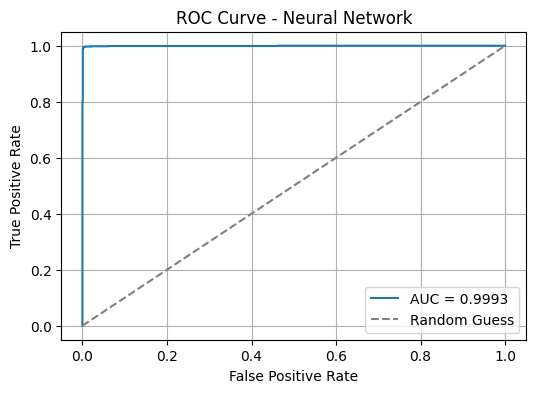

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability for class 1 (Disordered)
nn_probs = nn_pred_probs[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, nn_probs)
auc_score = roc_auc_score(y_test, nn_probs)

# Plot ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Neural Network")
plt.legend()
plt.grid(True)
plt.show()



In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("✅ Summary Metrics:")
print("Accuracy:", accuracy_score(y_test, nn_pred))
print("Precision:", precision_score(y_test, nn_pred))
print("Recall:", recall_score(y_test, nn_pred))
print("F1 Score:", f1_score(y_test, nn_pred))


✅ Summary Metrics:
Accuracy: 0.9951946179721288
Precision: 0.9961538461538462
Recall: 0.9942418426103646
F1 Score: 0.9951969260326609


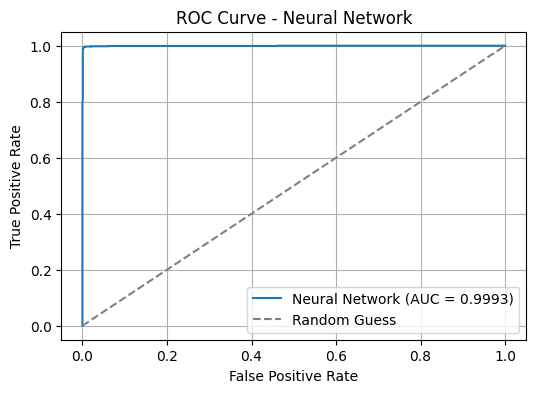

In [23]:
import pandas as pd
import joblib

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load test data
data_path = "/content/drive/MyDrive/speech_disorder_project/data"
X_test = pd.read_csv(f"{data_path}/X_test.csv")
y_test = pd.read_csv(f"{data_path}/y_test.csv").values.ravel()

# Load scaler
scaler = joblib.load("/content/drive/MyDrive/speech_disorder_project/model/scaler.pkl")
X_test_scaled = scaler.transform(X_test)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
from tensorflow.keras.models import load_model

# Load Random Forest model
rf_model = joblib.load("/content/drive/MyDrive/speech_disorder_project/model/random_forest_model.pkl")

# Load Neural Network model
nn_model = load_model("/content/drive/MyDrive/speech_disorder_project/model/nn_model.h5")


In [25]:
# Predict probabilities and classes
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
rf_preds = rf_model.predict(X_test_scaled)

nn_probs = nn_model.predict(X_test_scaled)[:, 1]
nn_preds = (nn_probs > 0.5).astype(int)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


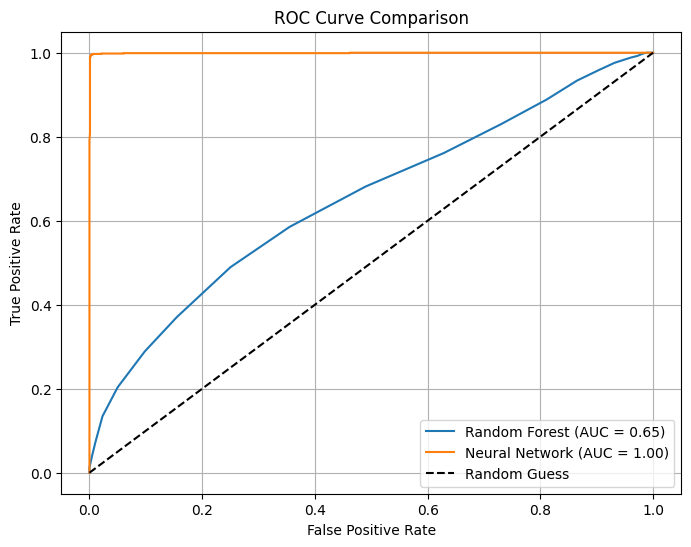

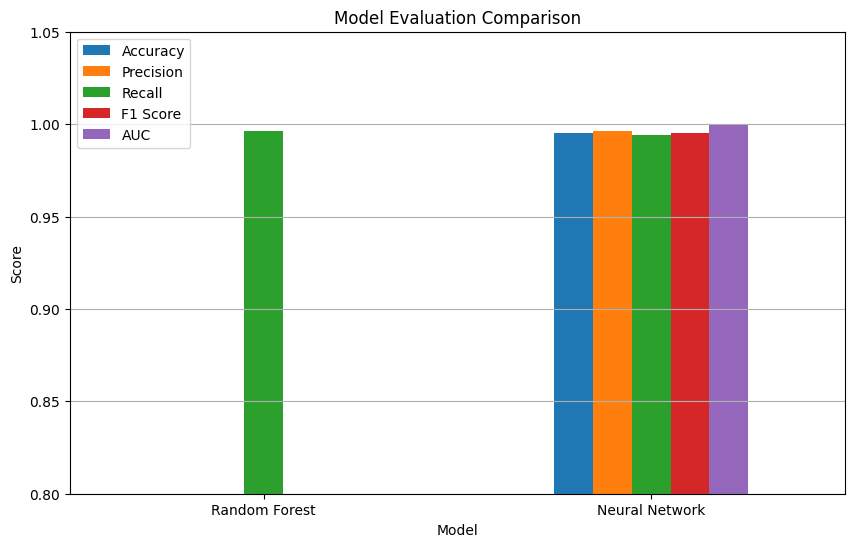

In [29]:
from sklearn.metrics import (
    roc_curve, roc_auc_score, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_probs)
auc_rf = roc_auc_score(y_test, rf_probs)
auc_nn = roc_auc_score(y_test, nn_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC = {auc_nn:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Metrics Comparison
metrics = {
    'Model': ['Random Forest', 'Neural Network'],
    'Accuracy': [accuracy_score(y_test, rf_preds), accuracy_score(y_test, nn_preds)],
    'Precision': [precision_score(y_test, rf_preds), precision_score(y_test, nn_preds)],
    'Recall': [recall_score(y_test, rf_preds), recall_score(y_test, nn_preds)],
    'F1 Score': [f1_score(y_test, rf_preds), f1_score(y_test, nn_preds)],
    'AUC': [auc_rf, auc_nn]
}

metrics_df = pd.DataFrame(metrics).set_index("Model")
metrics_df.plot(kind='bar', figsize=(10, 6), ylim=(0.8, 1.05), title="Evaluation Metric Comparison")
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.show()


📊 Classification Report - Random Forest:
               precision    recall  f1-score   support

         0.0       0.85      0.02      0.04      1039
         1.0       0.51      1.00      0.67      1042

    accuracy                           0.51      2081
   macro avg       0.68      0.51      0.36      2081
weighted avg       0.68      0.51      0.36      2081

📊 Classification Report - Neural Network:
               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      1039
         1.0       1.00      0.99      1.00      1042

    accuracy                           1.00      2081
   macro avg       1.00      1.00      1.00      2081
weighted avg       1.00      1.00      1.00      2081



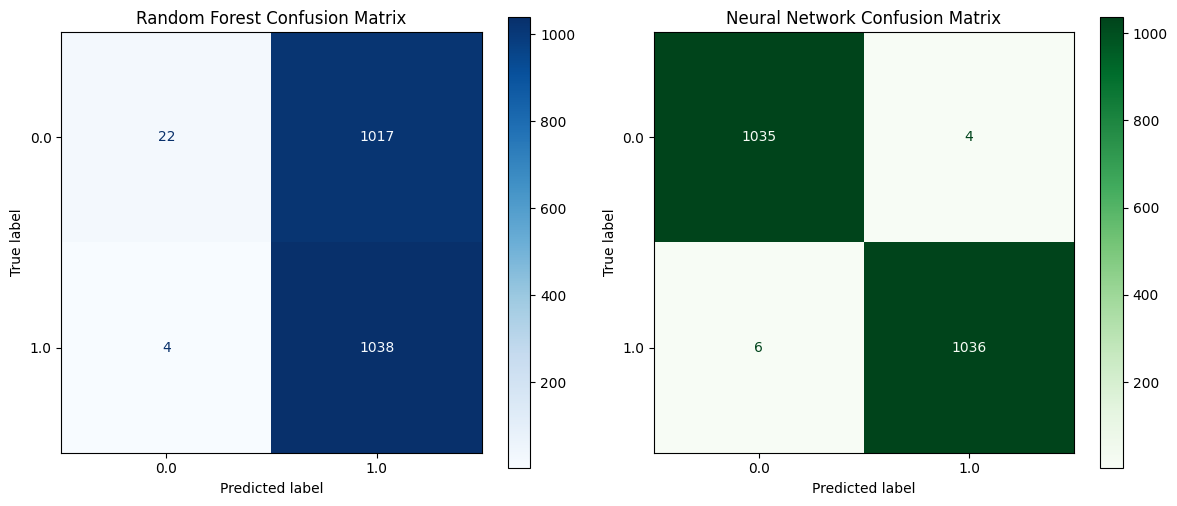

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 📝 Classification Reports
print("📊 Classification Report - Random Forest:\n", classification_report(y_test, rf_preds))
print("📊 Classification Report - Neural Network:\n", classification_report(y_test, nn_preds))

# 🔲 Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, ax=axes[0], cmap='Blues')
axes[0].set_title("Random Forest Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test, nn_preds, ax=axes[1], cmap='Greens')
axes[1].set_title("Neural Network Confusion Matrix")

plt.tight_layout()
plt.show()
